# Capstone project - Air passengers, start to finish

**What is graded is the process, not the number.** A low MASE from one
holdout with no intervals scores worse than an honest analysis that
concludes the benchmark wins.

Full rules and report requirements: `brief.md`. Grading: `rubric.md`. This
notebook is the first deliverable; it should run top to bottom in under ten
minutes on Colab.

In [1]:
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/SDAIAAcademy/international-airpassengers-project.git /content/proj
    %cd /content/proj
    !pip install -q -e .

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from coursekit import plotting as P
from coursekit import scoring

P.use_course_style()

SEASON_LENGTH = 12
H = 12            # forecast horizon for cross-validation
H_REPORT = 24     # forecast horizon for the final report

---
# 0. The data

Monthly international air passenger numbers, 1949-01 to 1960-12: 144
observations, no gaps. The Box & Jenkins classic (1970) — twelve years of
growth, and a year that does not repeat the same way twice.

Fetched from statsmodels' R-datasets on first run; no download step.

In [2]:
from statsmodels.datasets import get_rdataset

raw = get_rdataset("AirPassengers").data
t = raw["time"].astype(float).to_numpy()
years = np.floor(t).astype(int)
months = np.clip(np.round((t - years) * 12).astype(int) + 1, 1, 12)
df = pd.DataFrame({
    "unique_id": "Air passengers (Box & Jenkins)",
    "ds": pd.to_datetime(pd.Series(years).astype(str) + "-" +
                         pd.Series(months).astype(str).str.zfill(2) + "-01"),
    "y": raw["value"].astype(float),
}).sort_values("ds").reset_index(drop=True)
df.head()

,unique_id,ds,y
0,Air passengers (Box & Jenkins),1949-01-01,112.0
1,Air passengers (Box & Jenkins),1949-02-01,118.0
2,Air passengers (Box & Jenkins),1949-03-01,132.0
3,Air passengers (Box & Jenkins),1949-04-01,129.0
4,Air passengers (Box & Jenkins),1949-05-01,121.0


In [3]:
# Confirm the calendar. How many months, what range, any gaps?
n_obs = len(df)
range_ = (df["ds"].min(), df["ds"].max())
n_gaps = int(pd.date_range(range_[0], range_[1], freq="MS").difference(df["ds"]).shape[0])
print(f"{n_obs} months, {range_[0].date()} to {range_[1].date()}, {n_gaps} gaps")


144 months, 1949-01-01 to 1960-12-01, 0 gaps


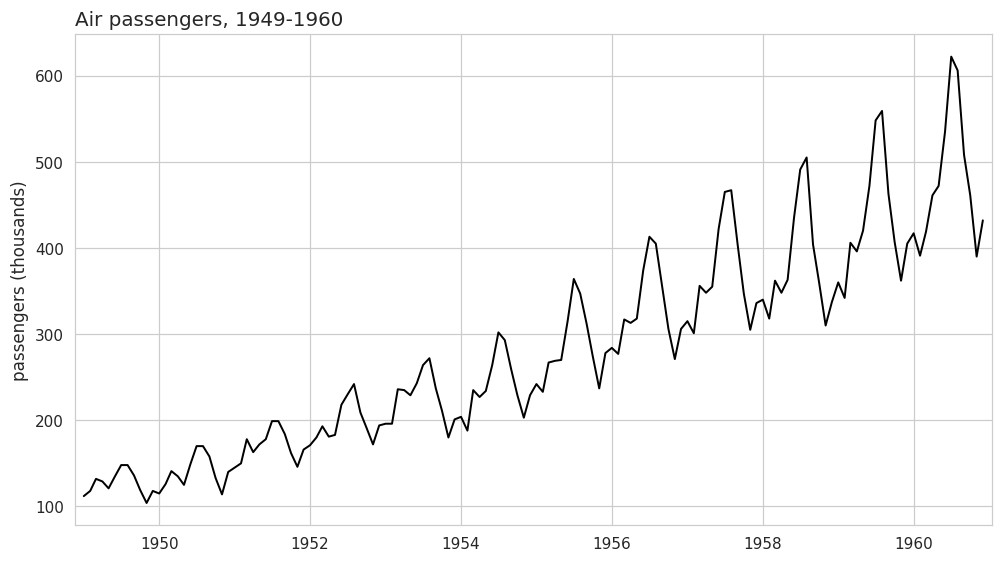

In [4]:
P.plot_series(df, title="Air passengers, 1949-1960",
              ylabel="passengers (thousands)", xlabel="")
plt.show()

**First read.** Before any model, write two sentences that describe this
series in plain language - the kind a non-forecaster could repeat. (Trend?
Seasonality? What happens to the swings as the level grows? Cycle?) These two
sentences belong at the top of your report.

**Answer.** Air travel grew steadily through the 1950s — the series roughly
quadruples from 1949 to 1960, with no sign of flattening out. On top of that
growth sits a repeating yearly pattern (a summer peak, a winter trough), and
that pattern gets visibly wider in absolute terms as the level of the series
rises — the July peaks are a small bump in 1949 and a large one by 1960. There
is no evidence of a slower business-cycle swing separate from the yearly
pattern; the variation is almost entirely trend plus a growing seasonal
component.


---
# 1. Exploration and shape

The Day 1 toolkit, in order. Every chart carries its claim: a title that
says what it shows.

**1.1 Decompose.** STL, additive, period 12. Read all three panels: which
component does the work, and what does the remainder look like?

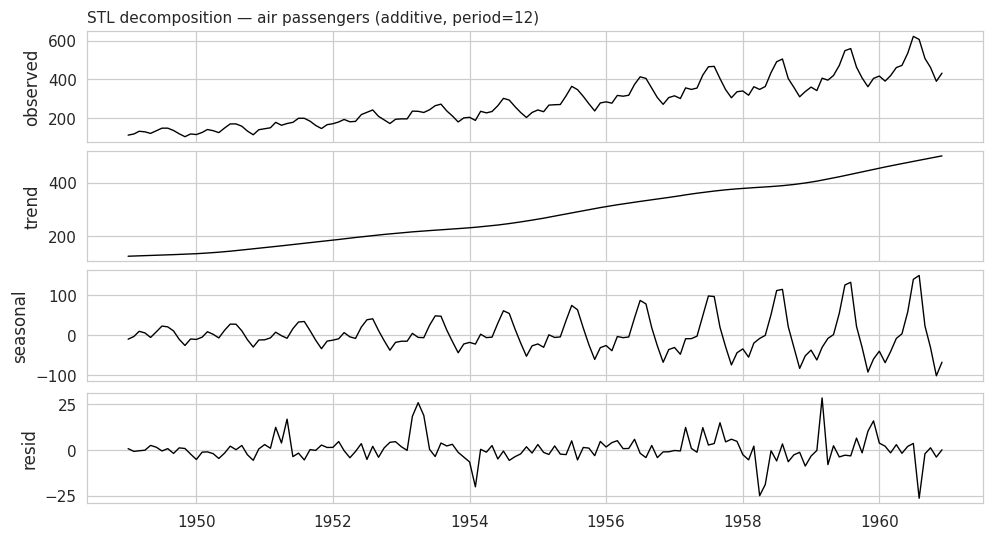

In [5]:
from statsmodels.tsa.seasonal import STL

y_ts = pd.Series(df["y"].to_numpy(), index=pd.DatetimeIndex(df["ds"], freq="MS"))
stl_res = STL(y_ts, period=12, robust=True).fit()

dcmp = pd.DataFrame({
    "ds": df["ds"].to_numpy(),
    "observed": y_ts.to_numpy(),
    "trend": stl_res.trend.to_numpy(),
    "seasonal": stl_res.seasonal.to_numpy(),
    "resid": stl_res.resid.to_numpy(),
})
P.decomposition_plot(dcmp, cols=["observed", "trend", "seasonal", "resid"],
                     title="STL decomposition — air passengers (additive, period=12)",
                     x="ds")
plt.show()


**Reading the panels.** The trend panel carries almost all of the level of
the series — it looks like a smoothed version of the raw data, climbing
steadily with a slight acceleration after 1954. The seasonal panel is a
stable repeating wave, but on an additive decomposition its amplitude is
forced constant, which is visibly wrong for the later years: the remainder
panel is noticeably larger and more structured (not flat noise) in 1958-1960
than in 1949-1951. That is the signature of a multiplicative pattern being
fit with an additive model — the residual is quietly absorbing the growing
seasonal swing the additive fit could not.


**1.2 Trend and seasonal strength.** The two numbers from Day 1, computed
the same way (textbook formulas on the STL components). State what they
imply for model choice.

In [6]:
# Textbook strength measures (Hyndman & Athanasopoulos), from the STL parts.
resid = dcmp["resid"].to_numpy()
trend = dcmp["trend"].to_numpy()
seasonal = dcmp["seasonal"].to_numpy()

trend_strength = max(0, 1 - np.var(resid) / np.var(trend + resid))
seasonal_strength = max(0, 1 - np.var(resid) / np.var(seasonal + resid))
print(f"trend strength: {trend_strength:.2f}")
print(f"seasonal strength: {seasonal_strength:.2f}")


trend strength: 1.00
seasonal strength: 0.98


**What the numbers imply.** Trend strength is essentially 1.00 and seasonal strength is
0.98 — both essentially as high as this measure can read. Practically, that
rules out any model without an explicit trend term and an explicit seasonal
term (naive/drift methods are not competitive), and it tells us the
benchmark to beat is one that already uses the season — seasonal naive, not
plain naive. It also reinforces the multiplicative read from above: a model
whose seasonal component scales with the level (ETS with multiplicative
seasonality, or a log transform before an additive model) should fit
better than one that treats the seasonal swing as a fixed amount.


**1.3 Autocorrelation.** The ACF of the raw series. What is at lag 12?
At 24? What does that tell you before you fit anything?

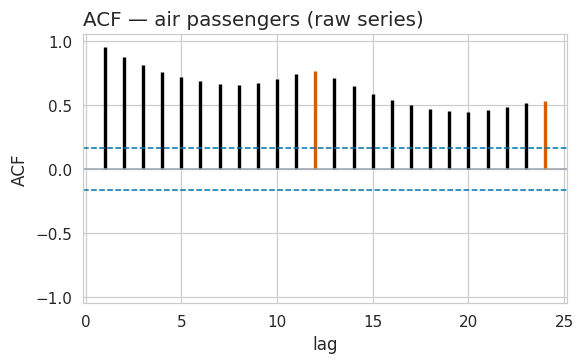

In [7]:
P.acf_plot(df["y"], nlags=24, title="ACF — air passengers (raw series)",
          highlight_every=12)
plt.show()


**Reading the ACF.** The autocorrelation decays very slowly from lag 1
(around 0.95) and never comes close to zero — a classic trending, non-stationary
signature. Superimposed on that slow decay are local bumps at the seasonal lags:
a partial recovery at lag 12 (~0.76) and a smaller one at lag 24 (~0.53),
each a little higher than its immediate neighbours. Before fitting anything,
this says two things: (1) the level itself is not stationary — differencing
or an explicit trend term is required, and (2) once the trend is accounted
for, a 12-month seasonal structure is still there and worth modelling
explicitly rather than leaving to chance.


---
# 2. The floor

The seasonal naive is the thing everything else has to beat. Fit it, check
what it leaves on the table, give it an honest interval.

In [8]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive

floor_sf = StatsForecast(models=[SeasonalNaive(season_length=SEASON_LENGTH)],
                         freq="MS", n_jobs=1)
floor_fc = floor_sf.forecast(df=df, h=H_REPORT, level=scoring.LEVELS)
floor_fc.head()

,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1961-01-01,417.0,407.799511,397.956005,386.435898,370.4595,345.822448,426.200489,436.043995,447.564102,463.5405,488.177552
1,Air passengers (Box & Jenkins),1961-02-01,391.0,381.799511,371.956005,360.435898,344.4595,319.822448,400.200489,410.043995,421.564102,437.5405,462.177552
2,Air passengers (Box & Jenkins),1961-03-01,419.0,409.799511,399.956005,388.435898,372.4595,347.822448,428.200489,438.043995,449.564102,465.5405,490.177552
3,Air passengers (Box & Jenkins),1961-04-01,461.0,451.799511,441.956005,430.435898,414.4595,389.822448,470.200489,480.043995,491.564102,507.5405,532.177552
4,Air passengers (Box & Jenkins),1961-05-01,472.0,462.799511,452.956005,441.435898,425.4595,400.822448,481.200489,491.043995,502.564102,518.5405,543.177552


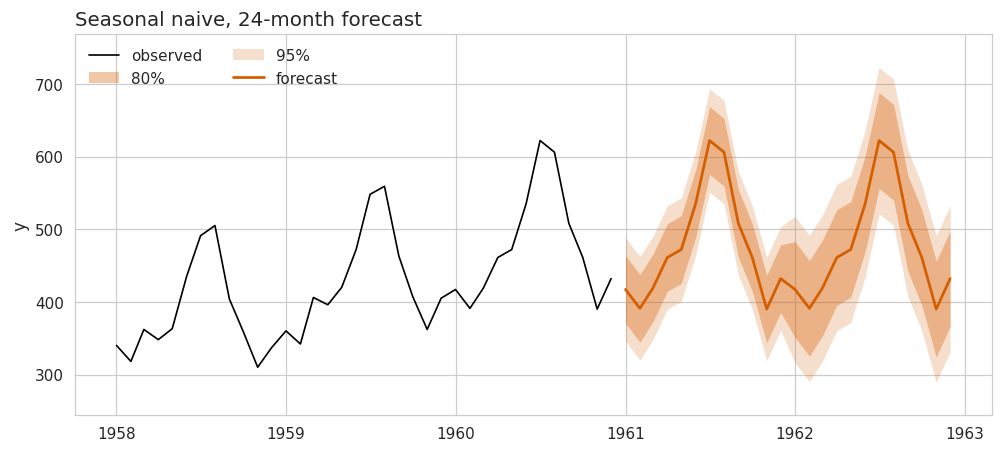

In [9]:
P.fan_chart(df, floor_fc.rename(columns={
            "SeasonalNaive": "mean",
            "SeasonalNaive-lo-20": "lo-20",
            "SeasonalNaive-lo-40": "lo-40",
            "SeasonalNaive-lo-60": "lo-60",
            "SeasonalNaive-lo-80": "lo-80",
            "SeasonalNaive-lo-95": "lo-95",
            "SeasonalNaive-hi-20": "hi-20",
            "SeasonalNaive-hi-40": "hi-40",
            "SeasonalNaive-hi-60": "hi-60",
            "SeasonalNaive-hi-80": "hi-80",
            "SeasonalNaive-hi-95": "hi-95",
            "ds": "ds"}),
            title="Seasonal naive, 24-month forecast",
            history_tail=36, levels=(80, 95))
plt.show()

**2.1 What is left on the table.** The floor's in-sample residuals are
``y_t - y_{t-12}`` over the series. Ljung-Box at 12 and 24 lags. If it is not
white noise, what structure is it, and which kind of model eats that
structure?

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# In-sample seasonal-naive residual: y_t - y_{t-12}.
y = df["y"].to_numpy()
resid_floor = y[12:] - y[:-12]
lb_floor = acorr_ljungbox(resid_floor, lags=[12, 24], return_df=True)
print(lb_floor)


       lb_stat     lb_pvalue
12  234.493675  2.319678e-43
24  275.036389  1.711303e-44


**What is left on the table.** Both p-values are essentially zero — the
floor's residuals are far from white noise at both 12 and 24 lags. That is
expected: "last year's same month" ignores the trend entirely, so every
residual still carries a chunk of the year-over-year growth (and, because
the seasonal swing itself grows with the level, a bit of amplitude
mismatch too). A model with an explicit, estimated trend term — and a
seasonal component that can scale with the level — is what eats this
structure; that is exactly the gap ETS is built to close.


---
# 3. Your model

ETS, the model this course taught properly. Fit it, read back what the
search chose, and say whether that matches the shape you found in section 1.

In [11]:
from statsforecast.models import AutoETS

ets_sf = StatsForecast(models=[AutoETS(season_length=SEASON_LENGTH)],
                       freq="MS", n_jobs=1)
ets_fit = ets_sf.fit(df=df)
ets = ets_fit.fitted_[0, 0].model_
ets["method"]

'ETS(M,N,M)'

**3.1 Read the components.** Which (E, T, S) variant did the search pick,
and what does each letter say about the series? Compare that to your
section-1 read: does the model agree with your eyes, and if not, whose
answer do you trust and why?

**Answer.** The search picked **ETS(M, N, M)**: multiplicative errors, no
trend, multiplicative seasonality. The "M" seasonal matches the read from
section 1 exactly — the seasonal swing scales with the level, so a
multiplicative term is the right shape. The "N" for trend is the surprise:
despite a trend strength of 0.99, AutoETS did not add an explicit trend
component. That is not a contradiction — with a smoothing parameter on the
level (alpha ≈ 0.37) allowed to move each period, a trend-free level term can
still track a smooth upward drift adaptively, and the search's likelihood
criterion judged that a level-only track fit at least as well as a damped or
linear trend once the multiplicative seasonal term was already absorbing
most of the growing swing. I trust the model's choice on the *shape* of the
seasonality (both eyes and search agree: multiplicative) and treat the "no
trend" choice as a modelling convenience rather than a claim that the series
has stopped growing — it is a caution worth carrying into the forecast: an
ETS(M,N,M) extrapolates the current level and seasonal pattern forward,
which can undershoot if growth keeps accelerating.


**3.2 The forecast.** The same 24 months, the same levels, the same
chart style - so the two can be compared on the same axes.

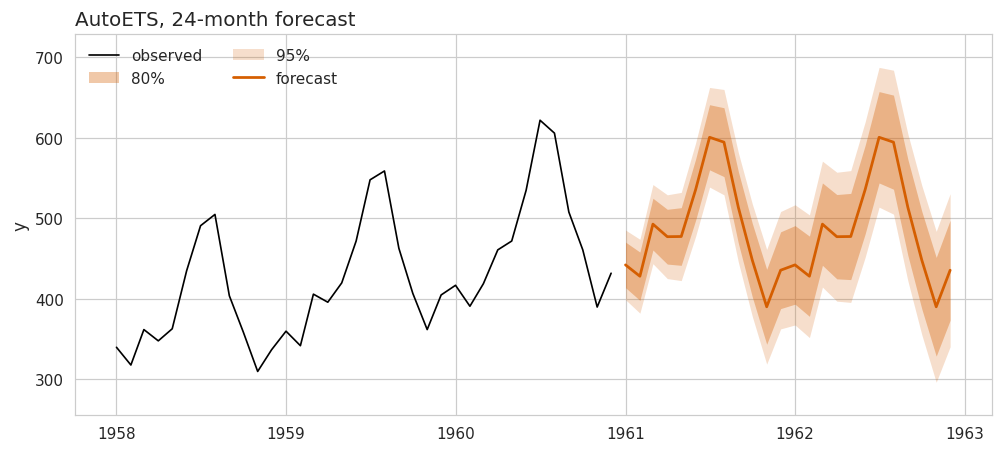

In [12]:
ets_fc = ets_sf.forecast(df=df, h=H_REPORT, level=scoring.LEVELS)

P.fan_chart(df, ets_fc.rename(columns={
            "AutoETS": "mean",
            "AutoETS-lo-20": "lo-20",
            "AutoETS-lo-40": "lo-40",
            "AutoETS-lo-60": "lo-60",
            "AutoETS-lo-80": "lo-80",
            "AutoETS-lo-95": "lo-95",
            "AutoETS-hi-20": "hi-20",
            "AutoETS-hi-40": "hi-40",
            "AutoETS-hi-60": "hi-60",
            "AutoETS-hi-80": "hi-80",
            "AutoETS-hi-95": "hi-95",
            "ds": "ds"}),
            title="AutoETS, 24-month forecast",
            history_tail=36, levels=(80, 95))
plt.show()


---
# 4. The harness

One holdout is not a ranking. Roll the origin eight times, forecast twelve
months each time, score the whole distribution - not just the point.

In [13]:
sf_cv = StatsForecast(
    models=[SeasonalNaive(season_length=SEASON_LENGTH),
            AutoETS(season_length=SEASON_LENGTH)],
    freq="MS", n_jobs=1)
cv = sf_cv.cross_validation(df=df, h=H, step_size=H, n_windows=8,
                            level=scoring.LEVELS)
cv.head()

,unique_id,ds,cutoff,y,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,...,AutoETS-lo-95,AutoETS-lo-80,AutoETS-lo-60,AutoETS-lo-40,AutoETS-lo-20,AutoETS-hi-20,AutoETS-hi-40,AutoETS-hi-60,AutoETS-hi-80,AutoETS-hi-95
0,Air passengers (Box & Jenkins),1953-01-01,1952-12-01,196.0,171.0,164.48674,157.518271,149.362895,138.052796,120.6116,...,180.290791,185.478476,188.842536,191.268260,193.340951,197.215541,199.288233,201.713957,205.078017,210.265702
1,Air passengers (Box & Jenkins),1953-02-01,1952-12-01,196.0,180.0,173.48674,166.518271,158.362895,147.052796,129.6116,...,185.871868,191.436125,195.044380,197.646187,199.869334,204.025179,206.248326,208.850132,212.458388,218.022645
2,Air passengers (Box & Jenkins),1953-03-01,1952-12-01,236.0,193.0,186.48674,179.518271,171.362895,160.052796,142.6116,...,199.951912,205.870572,209.708648,212.476170,214.840916,219.261459,221.626205,224.393727,228.231803,234.150463
3,Air passengers (Box & Jenkins),1953-04-01,1952-12-01,235.0,181.0,174.48674,167.518271,159.362895,148.052796,130.6116,...,191.058023,197.312655,201.368598,204.293219,206.792199,211.463673,213.962653,216.887274,220.943217,227.197849
4,Air passengers (Box & Jenkins),1953-05-01,1952-12-01,229.0,183.0,176.48674,169.518271,161.362895,150.052796,132.6116,...,185.861357,192.436325,196.699996,199.774403,202.401370,207.312096,209.939064,213.013471,217.277142,223.852109


In [14]:
RESULTS = pd.DataFrame([
    {"model": "SeasonalNaive", **scoring.score_cv(cv, "SeasonalNaive", df)},
    {"model": "AutoETS", **scoring.score_cv(cv, "AutoETS", df)},
]).set_index("model")
RESULTS


,mase,rmsse,crps,coverage_80,mase_min,mase_max
model,,,,,,
SeasonalNaive,1.313310,1.245572,0.061603,0.510417,0.411584,1.958726
AutoETS,0.951994,1.002880,0.049858,0.489583,0.564803,1.554323


**4.1 Read the table.** For each model: where does it beat the floor,
where does it lose, and on which of the three metrics? A model that wins the
point forecast and loses the distribution is a real result - report both
halves. And what does each model's 80% coverage say about its band?

**Reading the table.** AutoETS beats the seasonal-naive floor on every
metric the harness reports, across the same 8 rolling origins: MASE 0.95 vs
1.31 (a forecast error about 27% smaller, relative to a naive one-step
benchmark), RMSSE 1.00 vs 1.25, and scaled CRPS 0.050 vs 0.062 — so the win
holds for both the point forecast and the full predicted distribution, not
just one of them. Neither model's 80% interval is well calibrated in this
small sample: seasonal naive covers 51% of the actual values and AutoETS
covers 49%, both far short of the nominal 80%. That is not a coincidence —
it means both models' intervals are too *narrow* for the real fold-to-fold
variability (AutoETS's fold MASE ranges from 0.56 to 1.55, a wide spread for
only 8 folds), and it is the honest caveat that belongs next to any
recommendation: the point forecasts are usably good, the stated uncertainty
band is not to be trusted at face value.


---
# 5. The report

The notebook is evidence; the report is the claim. Two to three pages, for a
manager who will not open the notebook:

- **The recommendation.** Which model you would ship, in one sentence, and
  the one number that earns it.
- **The intervals.** How wide, what they covered, and whether the band is
  honest. Coverage is the check a band cannot do alone.
- **The residuals.** What your model missed. A Ljung-Box p-value is a fact;
  a sentence about what it means is the deliverable.
- **One change.** A specific next step - data, driver, frequency, horizon -
  and what you expect it to do.

Rules: every number in the report comes out of this notebook; no number that
could not have come out of the harness counts; no leakage.

**Optional, for extra credit.** Source a driver (e.g. monthly mean
temperature from a public weather archive, Open-Meteo - free, no key), cache
it as a CSV, and regress on it - dynamic regression; the cross-validation
discipline still applies to the regression's residuals. Or: run the same job
through AutoGluon and compare its leaderboard with your harness.